In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Waze.csv")
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [6]:
df.shape

(14999, 13)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [8]:
df.isnull().sum()

,0
ID,0
label,700
sessions,0
drives,0
total_sessions,0
n_days_after_onboarding,0
total_navigations_fav1,0
total_navigations_fav2,0
driven_km_drives,0
duration_minutes_drives,0


In [9]:
df_clean = df.dropna(subset=["label"]).copy()

In [10]:
df_clean.shape

(14299, 13)

In [11]:
df_clean["label"].value_counts()

,count
label,
retained,11763
churned,2536


In [12]:
churn_rate = (
    (df_clean["label"] == "churned").mean() * 100
)

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 17.74%


In [13]:
def engagement_tier(days):
    if days <= 10:
        return "Low"
    elif days <= 20:
        return "Medium"
    else:
        return "High"

df_clean["engagement_tier"] = (
    df_clean["activity_days"].apply(engagement_tier)
)

In [14]:
df_clean[
    ["activity_days", "engagement_tier"]
].head(10)

,activity_days,engagement_tier
0,28,High
1,13,Medium
2,14,Medium
3,7,Low
4,27,High
5,15,Medium
6,28,High
7,22,High
8,25,High
9,7,Low


In [15]:
df_clean["engagement_tier"].value_counts()

,count
engagement_tier,
High,4901
Low,4864
Medium,4534


In [16]:
df_clean["churned"] = (df_clean["label"] == "churned").astype(int)

In [17]:
churn_by_tier = (
    df_clean.groupby("engagement_tier")["churned"]
    .agg(["count", "sum", "mean"])
)

churn_by_tier

,count,sum,mean
engagement_tier,,,
High,4901,307,0.062640
Low,4864,1581,0.325041
Medium,4534,648,0.142920


In [18]:
churn_by_tier["churn_rate"] = (
    churn_by_tier["mean"] * 100
)

churn_by_tier

,count,sum,mean,churn_rate
engagement_tier,,,,
High,4901,307,0.062640,6.264028
Low,4864,1581,0.325041,32.504112
Medium,4534,648,0.142920,14.292016


In [19]:
low_churn = churn_by_tier.loc["Low", "churn_rate"]
high_churn = churn_by_tier.loc["High", "churn_rate"]

risk_ratio = low_churn / high_churn

print(f"Low-engagement users have {risk_ratio:.2f}x the churn rate of high-engagement users.")

Low-engagement users have 5.19x the churn rate of high-engagement users.


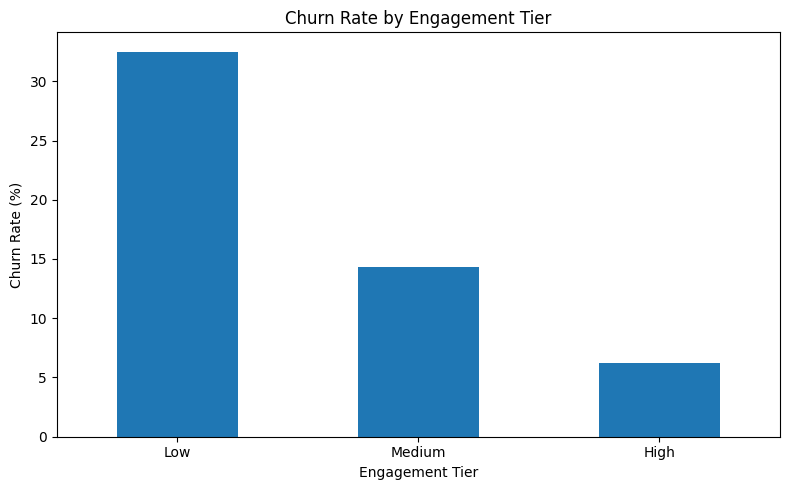

In [20]:
tier_order = ["Low", "Medium", "High"]

churn_rates = (
    df_clean.groupby("engagement_tier")["churned"]
    .mean()
    .reindex(tier_order) * 100
)

churn_rates.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Engagement Tier")
plt.xlabel("Engagement Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

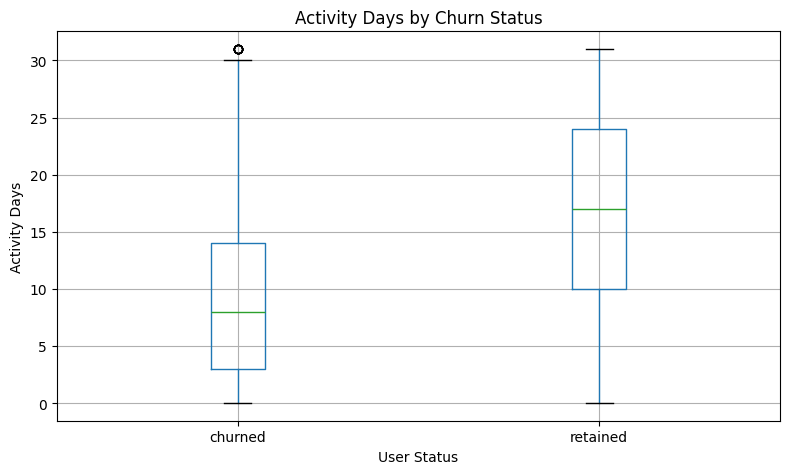

In [21]:
df_clean.boxplot(
    column="activity_days",
    by="label",
    figsize=(8, 5)
)

plt.title("Activity Days by Churn Status")
plt.suptitle("")
plt.xlabel("User Status")
plt.ylabel("Activity Days")
plt.tight_layout()
plt.show()

In [22]:
usage_comparison = (
    df_clean.groupby("label")[
        ["sessions", "drives", "driven_km_drives",
         "activity_days", "driving_days"]
    ]
    .mean()
    .round(2)
)

usage_comparison

,sessions,drives,driven_km_drives,activity_days,driving_days
label,,,,,
churned,87.24,72.73,4147.17,9.64,7.22
retained,79.20,66.08,4022.25,16.82,13.25


In [23]:
df_clean["km_per_driving_day"] = (
    df_clean["driven_km_drives"] /
    df_clean["driving_days"].replace(0, pd.NA)
)

df_clean.groupby("label")[
    "km_per_driving_day"
].median().round(2)

,km_per_driving_day
label,
churned,523.086749
retained,272.628549


In [24]:
import numpy as np

df_clean["km_per_driving_day"] = np.where(
    df_clean["driving_days"] > 0,
    df_clean["driven_km_drives"] / df_clean["driving_days"],
    np.nan
)

In [25]:
df_clean["km_per_driving_day"].dtype

dtype('float64')

In [26]:
df_clean["driving_activity_ratio"] = np.where(
    df_clean["activity_days"] > 0,
    df_clean["driving_days"] / df_clean["activity_days"],
    np.nan
)

In [28]:
df_clean.groupby("label")[
    ["km_per_driving_day", "driving_activity_ratio"]
].median().round(2)

,km_per_driving_day,driving_activity_ratio
label,,
churned,523.09,0.78
retained,272.63,0.80


In [29]:
df_clean.columns

Index(['ID', 'label', 'sessions', 'drives', 'total_sessions',
       'n_days_after_onboarding', 'total_navigations_fav1',
       'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives',
       'activity_days', 'driving_days', 'device', 'engagement_tier', 'churned',
       'km_per_driving_day', 'driving_activity_ratio'],
      dtype='object')

In [30]:
df_clean.to_csv(
    "waze_churn_tableau.csv",
    index=False
)